<a href="https://colab.research.google.com/github/chrishg23-jpg/HES-benchmark/blob/main/Matter007.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

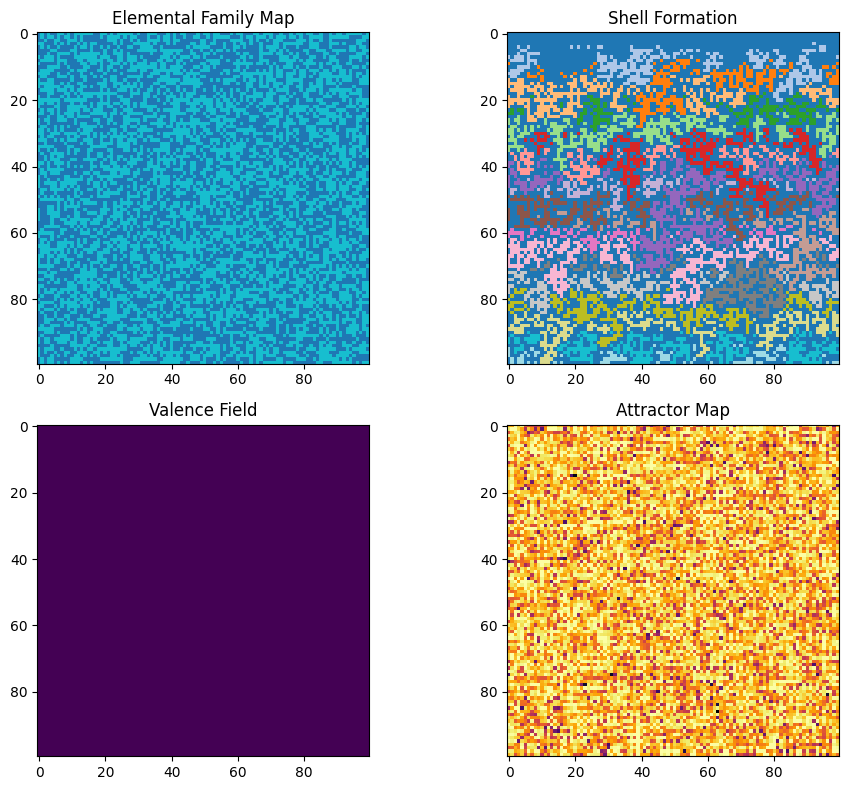

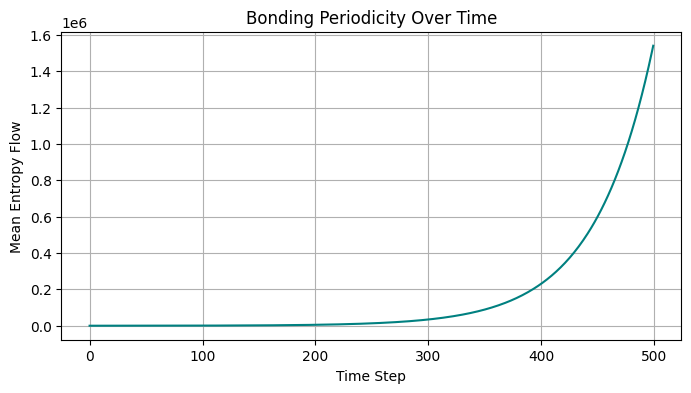

In [1]:
# 🧪 Matter007: Periodic Emergence – HES Lattice Simulation

import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import label

# --- Simulation Parameters ---
N = 100
steps = 500
entropy_seed_strength = 0.1
curvature_threshold = 0.05
bonding_threshold = 0.6

# --- Initialize Lattice ---
S = np.random.rand(N, N) * entropy_seed_strength
curvature_memory = np.zeros_like(S)
attractor_map = np.zeros_like(S)

# --- Evolution Function ---
def evolve(S):
    grad_x, grad_y = np.gradient(S)
    laplacian = np.gradient(grad_x)[0] + np.gradient(grad_y)[1]
    return S - 0.01 * laplacian

# --- Simulation Loop ---
for t in range(steps):
    S = evolve(S)
    curvature = np.abs(np.gradient(np.gradient(S)[0])[0] + np.gradient(np.gradient(S)[1])[1])
    curvature_memory += curvature
    attractor_map += (curvature > curvature_threshold).astype(float)

# --- Polarity & Valence ---
polarity = np.random.choice([-1, 1], size=(N, N))
valence = np.clip(curvature_memory // 5, 1, 4)

# --- Coupling & Bonding ---
grad_x, grad_y = np.gradient(S)
entropy_flow_magnitude = np.sqrt(grad_x**2 + grad_y**2)
coupling_strength = entropy_flow_magnitude * curvature_memory
bonding_map = (coupling_strength > bonding_threshold) & (polarity == -1)

# --- Shell Formation ---
shell_map, num_shells = label(bonding_map.astype(float))

# --- Elemental Family Classification ---
family_map = np.zeros_like(S)
family_map[(valence == 1) & (shell_map > 0)] = 1  # Light elements
family_map[(valence == 2) & (shell_map > 0)] = 2  # Transition elements
family_map[(valence >= 3) & (shell_map > 0)] = 3  # Heavy elements

# --- Bonding Periodicity ---
periodicity = np.zeros(steps)
for t in range(steps):
    S = evolve(S)
    grad_x, grad_y = np.gradient(S)
    entropy_flow = np.sqrt(grad_x**2 + grad_y**2)
    periodicity[t] = np.mean(entropy_flow)

# --- Visualization ---
fig, axs = plt.subplots(2, 2, figsize=(10, 8))
axs[0, 0].imshow(family_map, cmap='tab10'); axs[0, 0].set_title("Elemental Family Map")
axs[0, 1].imshow(shell_map, cmap='tab20'); axs[0, 1].set_title("Shell Formation")
axs[1, 0].imshow(valence, cmap='viridis'); axs[1, 0].set_title("Valence Field")
axs[1, 1].imshow(attractor_map, cmap='inferno'); axs[1, 1].set_title("Attractor Map")
plt.tight_layout(); plt.show()

# --- Periodicity Plot ---
plt.figure(figsize=(8, 4))
plt.plot(periodicity, color='teal')
plt.title("Bonding Periodicity Over Time")
plt.xlabel("Time Step")
plt.ylabel("Mean Entropy Flow")
plt.grid(True)
plt.show()
